# NB03b: B010 수치지형도 기반 경사도 분석 (로봇 배송 제약 레이어)

**목적**: 국토지리정보원 수치지형도(1:5000) 등고선·표고점 벡터 데이터로 DEM 생성 → 경사도 계산 → Green/Yellow/Red Zone 분류

**데이터 소스** (`00_data/수치지형도/{수정구|중원구|분당구}/*.zip`):
- `N3L_F0010000.shp` — **등고선** (LineString, `등고수치` 필드, EPSG:5186)
- `N3P_F0020000.shp` — **표고점** (Point, `수치` 필드, EPSG:5186)

**출력** (기존 NB03 파일명 충돌 없음, `_b010` 접미사):
- `processed/seongnam_dem_b010.tif` — DEM 래스터 (10m, EPSG:5179)
- `processed/seongnam_slope_b010.tif` — 경사도 래스터 (도, °)
- `processed/slope_zones_b010.gpkg` — Green/Yellow/Red Zone 벡터
- `processed/dong_slope_stats_b010.csv` — 행정동별 경사도 통계

**경사도 기준**:
- **Green Zone** (< 5°): 로봇 배송 가능 → 드론+로봇 Full 배송
- **Yellow Zone** (5° ~ 15°): 로봇 배송 제약 → 드론 스테이션에서 인간 수령
- **Red Zone** (≥ 15°): 로봇 배송 불가

In [1]:
import zipfile
import tempfile
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import geometry_mask, shapes
from rasterio.mask import mask as rio_mask
from scipy.interpolate import LinearNDInterpolator
from shapely.geometry import shape
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE    = Path(r'C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset')
RAW     = BASE / '00_data'
OUT     = BASE / 'processed'
TOPO    = RAW / '수치지형도'
OUT.mkdir(exist_ok=True)

# 경사도 Zone 기준
SLOPE_GREEN  = 5.0   # Green  < 5°
SLOPE_YELLOW = 15.0  # Yellow 5°~15°, Red ≥ 15°

# DEM 해상도 (EPSG:5179 미터 단위)
RESOLUTION = 10  # m

print(f'수치지형도 경로: {TOPO}')
print(f'출력 경로: {OUT}')

수치지형도 경로: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\00_data\수치지형도
출력 경로: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed


## 1. ZIP 파일 탐색 및 레이어 확인

3개 구 폴더의 모든 zip을 순회하며 고도 관련 레이어 존재 여부를 확인한다.  
타일 번호(예: `37709014`)가 동일한 zip은 중복 타일이므로 한 번만 처리한다.

In [2]:
GU_DIRS = ['수정구', '중원구', '분당구']

# 타일 번호 → (구, zip경로) 매핑  (중복 타일은 처음 발견된 것 사용)
tile_map = {}  # tile_id -> Path
for gu in GU_DIRS:
    for zp in sorted((TOPO / gu).glob('*.zip')):
        # 파일명 패턴: (B010)수치지도_37709014_2025_xxx.zip
        parts = zp.stem.replace('(B010)', '').strip().split('_')
        tile_id = next((p for p in parts if p.startswith('37709')), None)
        if tile_id and tile_id not in tile_map:
            tile_map[tile_id] = (gu, zp)

print(f'고유 타일 수: {len(tile_map)}')
for tid, (gu, zp) in sorted(tile_map.items()):
    print(f'  {tid}  [{gu}]  {zp.name}')

고유 타일 수: 35
  37709014  [수정구]  (B010)수치지도_37709014_2025_0000016719119.zip
  37709015  [수정구]  (B010)수치지도_37709015_2025_00000472107520.zip
  37709016  [수정구]  (B010)수치지도_37709016_2025_00000362300905.zip
  37709017  [수정구]  (B010)수치지도_37709017_2025_00000389025367.zip
  37709018  [수정구]  (B010)수치지도_37709018_2025_00000810149805.zip
  37709022  [수정구]  (B010)수치지도_37709022_2025_00000231803961.zip
  37709023  [수정구]  (B010)수치지도_37709023_2025_00000859750783.zip
  37709024  [수정구]  (B010)수치지도_37709024_2025_00000191290054.zip
  37709025  [수정구]  (B010)수치지도_37709025_2025_00000304577384.zip
  37709026  [수정구]  (B010)수치지도_37709026_2025_00000965929032.zip
  37709027  [수정구]  (B010)수치지도_37709027_2025_00000939268008.zip
  37709028  [중원구]  (B010)수치지도_37709028_2025_00000311243423.zip
  37709032  [수정구]  (B010)수치지도_37709032_2025_00000930132628.zip
  37709033  [수정구]  (B010)수치지도_37709033_2025_00000545533509.zip
  37709034  [수정구]  (B010)수치지도_37709034_2025_0000035883599.zip
  37709035  [수정구]  (B010)수치지도_37709035_2025_0

In [3]:
# 첫 번째 타일로 레이어 구조 검증
first_tile_id = sorted(tile_map.keys())[0]
_, first_zip = tile_map[first_tile_id]

print(f'=== 레이어 구조 검증: {first_zip.name} ===')
with zipfile.ZipFile(first_zip) as zf:
    shp_layers = sorted(set(
        Path(n).stem for n in zf.namelist() if n.endswith('.shp')
    ))
    print(f'  발견된 레이어: {shp_layers}')

CONTOUR_LAYER  = 'N3L_F0010000'  # 등고선 (등고수치 필드)
SPOTHT_LAYER   = 'N3P_F0020000'  # 표고점 (수치 필드)
CONTOUR_FIELD  = '등고수치'
SPOTHT_FIELD   = '수치'

found_contour = CONTOUR_LAYER in shp_layers
found_spotht  = SPOTHT_LAYER  in shp_layers

print(f'\n  등고선 레이어 ({CONTOUR_LAYER}): {"✓" if found_contour else "✗ NOT FOUND"}')
print(f'  표고점 레이어 ({SPOTHT_LAYER}):  {"✓" if found_spotht  else "✗ NOT FOUND"}')

if not found_contour and not found_spotht:
    raise RuntimeError(
        f'고도 레이어를 찾을 수 없습니다.\n'
        f'검사한 파일: {first_zip}\n'
        f'발견된 레이어: {shp_layers}\n'
        f'기대 레이어: {CONTOUR_LAYER}, {SPOTHT_LAYER}'
    )

print('\n레이어 구조 검증 완료 — 고도 데이터 로드 가능')

=== 레이어 구조 검증: (B010)수치지도_37709014_2025_0000016719119.zip ===
  발견된 레이어: ['N3A_A0010000', 'N3A_A0033320', 'N3A_A0053326', 'N3A_A0063321', 'N3A_A0070000', 'N3A_A0080000', 'N3A_A0100000', 'N3A_A0110020', 'N3A_B0010000', 'N3A_C0390000', 'N3A_C0423365', 'N3A_C0430000', 'N3A_D0010000', 'N3A_E0010001', 'N3A_E0032111', 'N3A_E0052114', 'N3A_G0010000', 'N3A_G0020000', 'N3A_H0010000', 'N3L_A0010000', 'N3L_A0020000', 'N3L_A0033330', 'N3L_A0123373', 'N3L_B0020000', 'N3L_C0050000', 'N3L_C0060000', 'N3L_C0070000', 'N3L_C0520000', 'N3L_E0020000', 'N3L_F0010000', 'N3L_F0030000', 'N3L_F0040000', 'N3L_G0030000', 'N3P_C0090000', 'N3P_C0285311', 'N3P_C0330000', 'N3P_C0380000', 'N3P_D0030000', 'N3P_E0042326', 'N3P_F0020000', 'N3P_H0020000', 'N3P_H0040000', 'N3P_H0059153']

  등고선 레이어 (N3L_F0010000): ✓
  표고점 레이어 (N3P_F0020000):  ✓

레이어 구조 검증 완료 — 고도 데이터 로드 가능


## 2. 등고선·표고점 로드 (전 타일 합산)

모든 타일 zip에서 `N3L_F0010000`(등고선)과 `N3P_F0020000`(표고점)을 메모리에 로드한다.  
타일 경계에서 발생하는 중복 형상은 UFID로 제거한다.

In [4]:
%%time

def load_layer_from_zip(zf: zipfile.ZipFile, layer_name: str, tmp_dir: Path) -> gpd.GeoDataFrame | None:
    """zip에서 단일 레이어를 임시 디렉토리로 추출 후 GeoDataFrame으로 반환."""
    names = zf.namelist()
    related = [n for n in names if Path(n).stem == layer_name]
    if not any(n.endswith('.shp') for n in related):
        return None
    for n in related:
        zf.extract(n, tmp_dir)
    shp = tmp_dir / (layer_name + '.shp')
    return gpd.read_file(shp)

contour_parts = []
spotht_parts  = []
missing_contour = []
missing_spotht  = []

with tempfile.TemporaryDirectory() as td:
    td = Path(td)
    for tile_id, (gu, zp) in sorted(tile_map.items()):
        tile_tmp = td / tile_id
        tile_tmp.mkdir()
        with zipfile.ZipFile(zp) as zf:
            gdf_c = load_layer_from_zip(zf, CONTOUR_LAYER, tile_tmp)
            gdf_s = load_layer_from_zip(zf, SPOTHT_LAYER,  tile_tmp)
        
        if gdf_c is not None:
            gdf_c['_tile'] = tile_id
            contour_parts.append(gdf_c)
        else:
            missing_contour.append(tile_id)
        
        if gdf_s is not None:
            gdf_s['_tile'] = tile_id
            spotht_parts.append(gdf_s)
        else:
            missing_spotht.append(tile_id)

if not contour_parts and not spotht_parts:
    raise RuntimeError('어떤 타일에서도 고도 레이어를 로드하지 못했습니다.')

# 병합 & UFID 기준 중복 제거
gdf_contour = pd.concat(contour_parts, ignore_index=True) if contour_parts else None
gdf_spotht  = pd.concat(spotht_parts,  ignore_index=True) if spotht_parts  else None

if gdf_contour is not None:
    before = len(gdf_contour)
    gdf_contour = gdf_contour.drop_duplicates('UFID').reset_index(drop=True)
    print(f'등고선: {before:,} → 중복 제거 후 {len(gdf_contour):,}개 (CRS: {gdf_contour.crs})')
    print(f'  등고수치 범위: {gdf_contour[CONTOUR_FIELD].min():.0f}m ~ {gdf_contour[CONTOUR_FIELD].max():.0f}m')
    print(f'  등고수치 유니크값 수: {gdf_contour[CONTOUR_FIELD].nunique()}')

if gdf_spotht is not None:
    before = len(gdf_spotht)
    gdf_spotht = gdf_spotht.drop_duplicates('UFID').reset_index(drop=True)
    print(f'\n표고점: {before:,} → 중복 제거 후 {len(gdf_spotht):,}개')
    print(f'  수치 범위: {gdf_spotht[SPOTHT_FIELD].min():.1f}m ~ {gdf_spotht[SPOTHT_FIELD].max():.1f}m')

if missing_contour:
    print(f'\n⚠ 등고선 없는 타일: {missing_contour}')
if missing_spotht:
    print(f'⚠ 표고점 없는 타일: {missing_spotht}')

등고선: 9,437 → 중복 제거 후 9,437개 (CRS: EPSG:5186)
  등고수치 범위: 15m ~ 610m
  등고수치 유니크값 수: 120

표고점: 17,856 → 중복 제거 후 17,856개
  수치 범위: 12.6m ~ 614.0m
CPU times: total: 6.66 s
Wall time: 8.51 s


## 3. CRS 변환 (EPSG:5186 → 5179) & 성남시 경계 클리핑

In [5]:
# 성남시 경계 로드
boundary_gpkg = OUT / 'seongnam_boundary.gpkg'
if boundary_gpkg.exists():
    seongnam_dong = gpd.read_file(boundary_gpkg, layer='dong_5179')
    city_5179     = gpd.read_file(boundary_gpkg, layer='city').to_crs(epsg=5179)
    seongnam_4326 = gpd.read_file(boundary_gpkg, layer='dong')
    print('NB01 경계 파일 사용')
else:
    # Fallback: BND_ADM_DONG_PG 직접 사용
    print('⚠ seongnam_boundary.gpkg 없음 → BND_ADM_DONG_PG 로드')
    gdf_all = gpd.read_file(RAW / 'BND_ADM_DONG_PG' / 'BND_ADM_DONG_PG.shp')
    seongnam_dong = gdf_all[gdf_all['ADM_CD'].astype(str).str[:5].isin(['31021','31022','31023'])].copy()
    seongnam_dong = seongnam_dong.to_crs(epsg=5179)
    city_5179     = seongnam_dong.dissolve()
    seongnam_4326 = seongnam_dong.to_crs(epsg=4326)

bounds_5179 = seongnam_dong.total_bounds  # (minx, miny, maxx, maxy)
print(f'성남시 Bounds (EPSG:5179): {bounds_5179.round(0)}')

# CRS 변환 5186 → 5179
if gdf_contour is not None:
    gdf_contour = gdf_contour.to_crs(epsg=5179)
    # 성남시 경계로 클리핑 (경계 밖 타일 데이터 제거)
    gdf_contour = gpd.clip(gdf_contour, city_5179)
    print(f'\n등고선 클리핑 후: {len(gdf_contour):,}개')

if gdf_spotht is not None:
    gdf_spotht = gdf_spotht.to_crs(epsg=5179)
    gdf_spotht = gpd.sjoin(gdf_spotht, city_5179[['geometry']], predicate='within', how='inner')
    gdf_spotht = gdf_spotht.drop(columns='index_right', errors='ignore')
    print(f'표고점 클리핑 후: {len(gdf_spotht):,}개')

NB01 경계 파일 사용
성남시 Bounds (EPSG:5179): [ 958183. 1926110.  973093. 1941780.]

등고선 클리핑 후: 6,041개
표고점 클리핑 후: 12,943개


## 4. 등고선·표고점 → 고도 샘플 포인트 생성

등고선 LineString을 **약 10m 간격으로 조밀화**하여 (x, y, z) 샘플 포인트를 추출한다.  
표고점은 그대로 (x, y, 수치)로 사용한다.  
이 샘플들로 Delaunay 삼각분할 기반 선형 보간 DEM을 생성한다.

In [6]:
%%time

DENSIFY_STEP = 10.0  # 등고선 조밀화 간격 (m)

sample_xy  = []
sample_z   = []

# --- 등고선 샘플 추출 ---
if gdf_contour is not None and len(gdf_contour) > 0:
    print('등고선 조밀화 중...')
    for _, row in gdf_contour.iterrows():
        elev = row[CONTOUR_FIELD]
        if pd.isna(elev):
            continue
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        # Multi* 처리
        from shapely.geometry import MultiLineString
        geoms = list(geom.geoms) if hasattr(geom, 'geoms') else [geom]
        for g in geoms:
            length = g.length
            if length == 0:
                continue
            # DENSIFY_STEP 간격으로 포인트 샘플링
            n_pts = max(2, int(length / DENSIFY_STEP) + 1)
            distances = np.linspace(0, length, n_pts)
            for d in distances:
                pt = g.interpolate(d)
                sample_xy.append((pt.x, pt.y))
                sample_z.append(elev)
    print(f'  등고선 샘플 포인트: {len(sample_z):,}개')

# --- 표고점 샘플 추출 ---
if gdf_spotht is not None and len(gdf_spotht) > 0:
    n_before = len(sample_z)
    for _, row in gdf_spotht.iterrows():
        elev = row[SPOTHT_FIELD]
        if pd.isna(elev):
            continue
        pt = row.geometry
        sample_xy.append((pt.x, pt.y))
        sample_z.append(elev)
    print(f'표고점 샘플 포인트: {len(sample_z) - n_before:,}개')

sample_xy = np.array(sample_xy)
sample_z  = np.array(sample_z)
print(f'\n전체 샘플 포인트: {len(sample_z):,}개')
print(f'고도 범위: {sample_z.min():.0f}m ~ {sample_z.max():.0f}m')

if len(sample_z) == 0:
    raise RuntimeError('유효한 고도 샘플 포인트가 없습니다. 입력 데이터를 확인하세요.')

등고선 조밀화 중...
  등고선 샘플 포인트: 746,137개
표고점 샘플 포인트: 12,943개

전체 샘플 포인트: 759,080개
고도 범위: 13m ~ 605m
CPU times: total: 14.5 s
Wall time: 14.6 s


## 5. DEM 보간 (LinearNDInterpolator)

Delaunay 삼각분할 기반 선형 보간으로 10m × 10m 격자 DEM 생성.  
성남시 경계 외부 픽셀은 NaN으로 마스킹한다.

In [7]:
%%time

# 래스터 격자 정의 (EPSG:5179 미터 단위)
buf = 200  # 경계 버퍼 (m)
x_min = bounds_5179[0] - buf
y_min = bounds_5179[1] - buf
x_max = bounds_5179[2] + buf
y_max = bounds_5179[3] + buf

n_cols = int((x_max - x_min) / RESOLUTION)
n_rows = int((y_max - y_min) / RESOLUTION)
print(f'DEM 격자: {n_rows} rows × {n_cols} cols  ({RESOLUTION}m 해상도)')
print(f'예상 메모리: {n_rows * n_cols * 4 / 1024**2:.0f} MB')

# 격자 좌표 생성
xi = np.linspace(x_min, x_max, n_cols)
yi = np.linspace(y_min, y_max, n_rows)
grid_x, grid_y = np.meshgrid(xi, yi[::-1])  # y는 상단=큰값 (래스터 관례)

# Delaunay 삼각분할 보간기 구성
print('보간기 구성 중 (Delaunay 삼각분할)...')
interp = LinearNDInterpolator(sample_xy, sample_z)

# 격자 전체 보간 (메모리 절약을 위해 행 단위 처리)
print('DEM 보간 중...')
dem = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
CHUNK = 100  # 한번에 처리할 행 수
for r_start in range(0, n_rows, CHUNK):
    r_end = min(r_start + CHUNK, n_rows)
    pts = np.column_stack([
        grid_x[r_start:r_end].ravel(),
        grid_y[r_start:r_end].ravel()
    ])
    dem[r_start:r_end] = interp(pts).reshape(r_end - r_start, n_cols)
    if r_start % 500 == 0:
        print(f'  {r_start}/{n_rows} 행 완료...')

print(f'\nDEM 생성 완료')
valid_pct = np.sum(~np.isnan(dem)) / dem.size * 100
print(f'유효 픽셀: {valid_pct:.1f}% (NaN = 샘플 포인트 볼록껍질 외부)')
print(f'고도 범위: {np.nanmin(dem):.0f}m ~ {np.nanmax(dem):.0f}m')
print(f'평균 고도: {np.nanmean(dem):.0f}m')

DEM 격자: 1607 rows × 1531 cols  (10m 해상도)
예상 메모리: 9 MB
보간기 구성 중 (Delaunay 삼각분할)...
DEM 보간 중...
  0/1607 행 완료...
  500/1607 행 완료...
  1000/1607 행 완료...
  1500/1607 행 완료...

DEM 생성 완료
유효 픽셀: 64.7% (NaN = 샘플 포인트 볼록껍질 외부)
고도 범위: 13m ~ 605m
평균 고도: 140m
CPU times: total: 7.89 s
Wall time: 8.03 s


In [8]:
# 성남시 경계 마스킹 (경계 외부 → NaN)
transform_5179 = from_bounds(x_min, y_min, x_max, y_max, n_cols, n_rows)

city_mask = geometry_mask(
    city_5179.geometry,
    out_shape=(n_rows, n_cols),
    transform=transform_5179,
    invert=True  # True = 경계 내부
)
dem[~city_mask] = np.nan

valid_pct = np.sum(~np.isnan(dem)) / dem.size * 100
print(f'경계 마스킹 후 유효 픽셀: {valid_pct:.1f}%')

# GeoTIFF 저장
dem_path = OUT / 'seongnam_dem_b010.tif'
with rasterio.open(
    dem_path, 'w', driver='GTiff',
    height=n_rows, width=n_cols, count=1,
    dtype='float32', crs='EPSG:5179',
    transform=transform_5179, nodata=np.nan,
) as dst:
    dst.write(dem, 1)
print(f'저장: {dem_path}')

경계 마스킹 후 유효 픽셀: 57.5%
저장: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\seongnam_dem_b010.tif


## 6. 경사도 계산

경사도(slope) = arctan(√(∂z/∂x)² + (∂z/∂y)²)  
EPSG:5179는 미터 단위이므로 pixel 크기 = `RESOLUTION` (m).

In [9]:
# NaN을 인접 평균으로 임시 채운 뒤 gradient 계산 (경계 픽셀 artifact 방지)
dem_filled = dem.copy()
nan_mask = np.isnan(dem_filled)

# 간단한 NaN 채우기: 전체 평균으로 대체 (gradient 계산 후 다시 NaN 처리)
dem_filled[nan_mask] = np.nanmean(dem_filled)

dz_dy, dz_dx = np.gradient(dem_filled, RESOLUTION, RESOLUTION)
slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
slope_deg = np.degrees(slope_rad).astype(np.float32)

# 경계 외부 NaN 복원
slope_deg[nan_mask] = np.nan

print(f'경사도 계산 완료')
print(f'범위: {np.nanmin(slope_deg):.1f}° ~ {np.nanmax(slope_deg):.1f}°')
print(f'평균: {np.nanmean(slope_deg):.1f}°')

green_pct  = np.nanmean(slope_deg < SLOPE_GREEN) * 100
yellow_pct = np.nanmean((slope_deg >= SLOPE_GREEN) & (slope_deg < SLOPE_YELLOW)) * 100
red_pct    = np.nanmean(slope_deg >= SLOPE_YELLOW) * 100
print(f'\nGreen  Zone (< {SLOPE_GREEN}°):  {green_pct:.1f}%')
print(f'Yellow Zone ({SLOPE_GREEN}°~{SLOPE_YELLOW}°): {yellow_pct:.1f}%')
print(f'Red    Zone (≥ {SLOPE_YELLOW}°):  {red_pct:.1f}%')

# 경사도 GeoTIFF 저장
slope_path = OUT / 'seongnam_slope_b010.tif'
with rasterio.open(
    slope_path, 'w', driver='GTiff',
    height=n_rows, width=n_cols, count=1,
    dtype='float32', crs='EPSG:5179',
    transform=transform_5179, nodata=np.nan,
) as dst:
    dst.write(slope_deg, 1)
print(f'\n저장: {slope_path}')

경사도 계산 완료
범위: 0.0° ~ 88.3°
평균: 12.9°

Green  Zone (< 5.0°):  18.8%
Yellow Zone (5.0°~15.0°): 15.6%
Red    Zone (≥ 15.0°):  23.1%

저장: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\seongnam_slope_b010.tif


## 7. Zone 분류 및 벡터화

경사도 래스터를 Green/Yellow/Red 3개 Zone으로 분류하고 벡터 폴리곤으로 변환한다.  
인접 같은 Zone 픽셀을 dissolve하여 파일 크기를 줄인다.

In [10]:
# Zone 래스터 (0=유효 외부, 1=Green, 2=Yellow, 3=Red)
zone_arr = np.zeros_like(slope_deg, dtype=np.uint8)
zone_arr[~nan_mask & (slope_deg <  SLOPE_GREEN)]                          = 1  # Green
zone_arr[~nan_mask & (slope_deg >= SLOPE_GREEN) & (slope_deg < SLOPE_YELLOW)] = 2  # Yellow
zone_arr[~nan_mask & (slope_deg >= SLOPE_YELLOW)]                          = 3  # Red

# rasterio.features.shapes로 벡터화 (같은 값 연결)
zone_shapes = [
    (shape(s), v)
    for s, v in shapes(zone_arr, transform=transform_5179)
    if int(v) in (1, 2, 3)
]

ZONE_LABELS = {1: 'Green', 2: 'Yellow', 3: 'Red'}
gdf_zones = gpd.GeoDataFrame(
    [
        {'zone_id': int(v), 'zone': ZONE_LABELS[int(v)], 'geometry': geom}
        for geom, v in zone_shapes
    ],
    crs='EPSG:5179'
)

# Zone별 dissolve (인접 폴리곤 합치기)
gdf_zones_dissolved = gdf_zones.dissolve(by='zone_id').reset_index()
gdf_zones_dissolved['zone'] = gdf_zones_dissolved['zone_id'].map(ZONE_LABELS)
gdf_zones_dissolved['area_km2'] = gdf_zones_dissolved.geometry.area / 1e6

print('Zone 면적:')
for _, row in gdf_zones_dissolved.sort_values('zone_id').iterrows():
    print(f'  {row["zone"]:6s}: {row["area_km2"]:.2f} km²')

# GeoPackage 저장
zone_path = OUT / 'slope_zones_b010.gpkg'
gdf_zones_dissolved.to_file(zone_path, driver='GPKG')
print(f'\n저장: {zone_path}')

Zone 면적:
  Green : 46.28 km²
  Yellow: 38.26 km²
  Red   : 56.84 km²

저장: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\slope_zones_b010.gpkg


## 8. 행정동별 경사도 통계

각 행정동 경계로 경사도 래스터를 마스킹하여 동별 평균·최대 경사도와 Zone 비율을 계산한다.

In [11]:
dong_stats = []

for _, row in seongnam_dong.iterrows():
    # 행정동 마스크
    dong_mask = geometry_mask(
        [row.geometry],
        out_shape=(n_rows, n_cols),
        transform=transform_5179,
        invert=True
    )
    pixels = slope_deg[dong_mask]
    pixels = pixels[~np.isnan(pixels)]
    
    if len(pixels) == 0:
        continue
    
    dong_stats.append({
        'SHP_ADM_CD': row.get('SHP_ADM_CD', row.get('ADM_CD', '')),
        'ADM_NM':     row.get('ADM_NM', ''),
        'GU_NM':      row.get('GU_NM', ''),
        'avg_slope':  float(np.mean(pixels)),
        'max_slope':  float(np.max(pixels)),
        'green_pct':  float(np.mean(pixels <  SLOPE_GREEN) * 100),
        'yellow_pct': float(np.mean((pixels >= SLOPE_GREEN) & (pixels < SLOPE_YELLOW)) * 100),
        'red_pct':    float(np.mean(pixels >= SLOPE_YELLOW) * 100),
        'n_pixels':   len(pixels),
    })

df_stats = pd.DataFrame(dong_stats)
df_stats = df_stats.sort_values('avg_slope', ascending=False).reset_index(drop=True)

stats_path = OUT / 'dong_slope_stats_b010.csv'
df_stats.to_csv(stats_path, index=False, encoding='utf-8-sig')
print(f'저장: {stats_path}  ({len(df_stats)} 개 동)')

print('\n▶ 경사도 높은 동 Top 10:')
print(df_stats[['ADM_NM','GU_NM','avg_slope','max_slope','green_pct','red_pct']].head(10).to_string(index=False, float_format='{:.1f}'.format))

print('\n▶ 경사도 낮은 동 Top 5:')
print(df_stats[['ADM_NM','GU_NM','avg_slope','green_pct']].tail(5).to_string(index=False, float_format='{:.1f}'.format))

저장: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\dong_slope_stats_b010.csv  (50 개 동)

▶ 경사도 높은 동 Top 10:
ADM_NM GU_NM  avg_slope  max_slope  green_pct  red_pct
  은행2동   중원구       22.3       88.0        9.8     68.8
   양지동   수정구       19.7       86.3       12.0     64.6
 상대원1동   중원구       18.3       88.0       17.1     59.9
   고등동   수정구       16.8       88.3       17.7     57.1
   운중동   분당구       16.2       87.8       16.2     53.5
   도촌동   중원구       15.6       86.7       23.8     50.3
   신촌동   수정구       15.1       86.0       15.0     48.7
   시흥동   수정구       14.4       88.0       27.0     46.3
  야탑3동   분당구       13.5       87.1       23.5     42.8
  정자3동   분당구       13.3       86.0       34.7     44.6

▶ 경사도 낮은 동 Top 5:
ADM_NM GU_NM  avg_slope  green_pct
   정자동   분당구        2.4       88.3
  야탑1동   분당구        2.4       86.7
  이매2동   분당구        2.4       91.3
  야탑2동   분당구        2.1       90.9
  수내1동   분당구        1.4       94.1


## 9. 시각적 검증 (QA 지도)

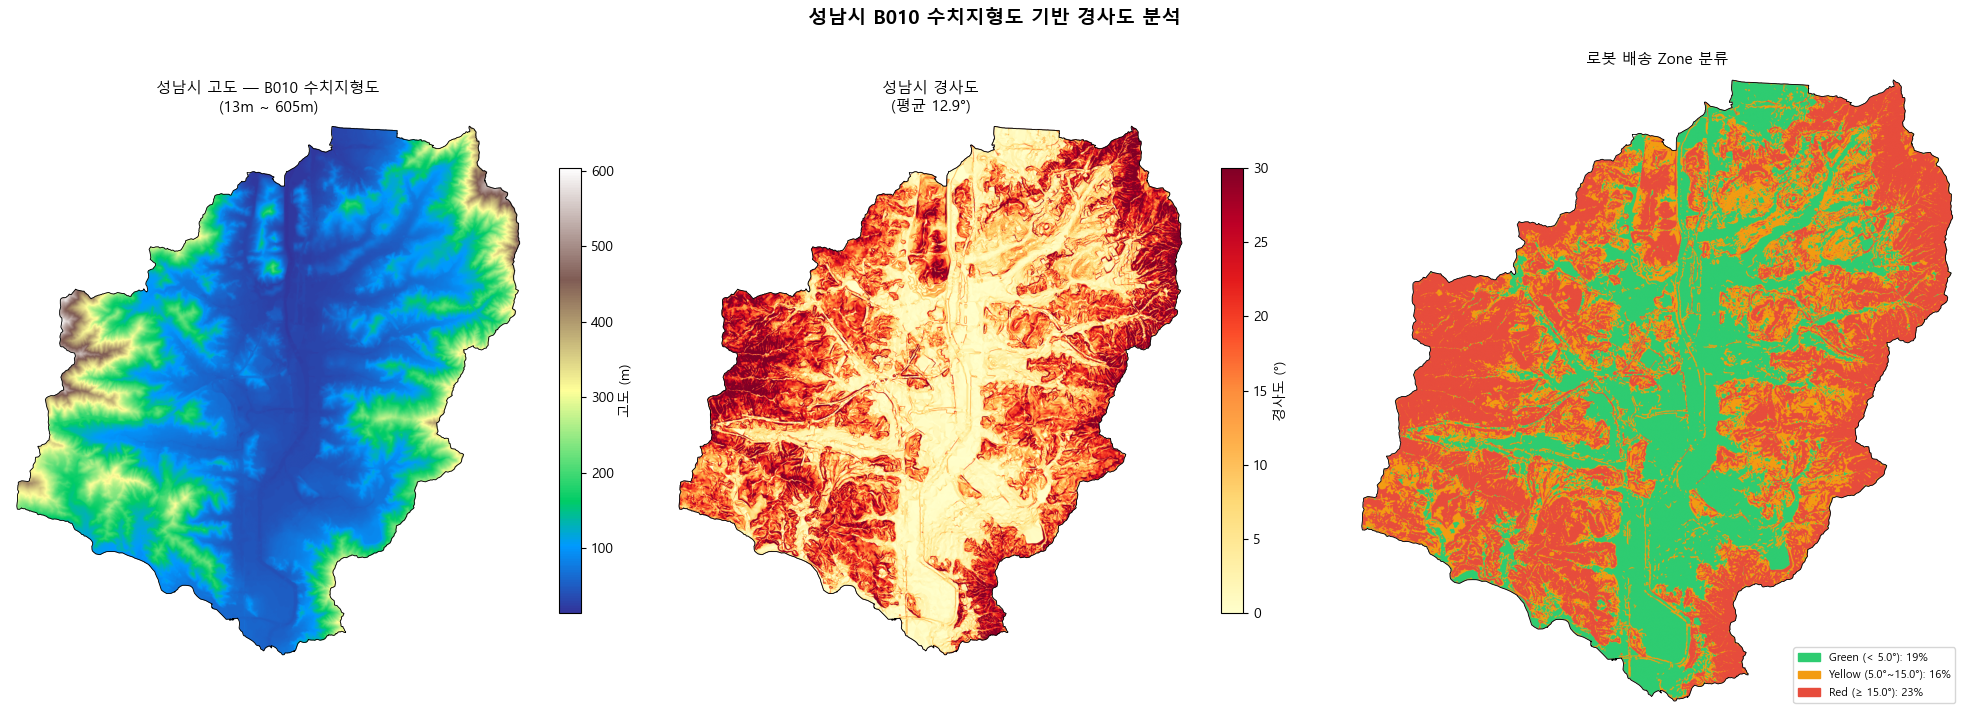

In [12]:
extent_5179 = [x_min, x_max, y_min, y_max]
boundary_plot = city_5179.to_crs(epsg=5179)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- 1) 고도 지도 ---
im1 = axes[0].imshow(
    dem, cmap='terrain',
    extent=[x_min, x_max, y_min, y_max],
    origin='upper', aspect='equal'
)
boundary_plot.boundary.plot(ax=axes[0], color='black', linewidth=0.6)
plt.colorbar(im1, ax=axes[0], shrink=0.7, label='고도 (m)')
axes[0].set_title(f'성남시 고도 — B010 수치지형도\n'
                  f'({np.nanmin(dem):.0f}m ~ {np.nanmax(dem):.0f}m)', fontsize=11)
axes[0].set_axis_off()

# --- 2) 경사도 지도 ---
im2 = axes[1].imshow(
    slope_deg, cmap='YlOrRd', vmin=0, vmax=30,
    extent=[x_min, x_max, y_min, y_max],
    origin='upper', aspect='equal'
)
boundary_plot.boundary.plot(ax=axes[1], color='black', linewidth=0.6)
plt.colorbar(im2, ax=axes[1], shrink=0.7, label='경사도 (°)')
axes[1].set_title(f'성남시 경사도\n'
                  f'(평균 {np.nanmean(slope_deg):.1f}°)', fontsize=11)
axes[1].set_axis_off()

# --- 3) Zone 지도 ---
zone_display = zone_arr.astype(float)
zone_display[zone_arr == 0] = np.nan

cmap_zone = ListedColormap(['#2ecc71', '#f39c12', '#e74c3c'])
norm_zone  = BoundaryNorm([1, 2, 3, 4], cmap_zone.N)

axes[2].imshow(
    zone_display, cmap=cmap_zone, norm=norm_zone,
    extent=[x_min, x_max, y_min, y_max],
    origin='upper', aspect='equal'
)
boundary_plot.boundary.plot(ax=axes[2], color='black', linewidth=0.6)

legend_patches = [
    Patch(color='#2ecc71', label=f'Green (< {SLOPE_GREEN}°): {green_pct:.0f}%'),
    Patch(color='#f39c12', label=f'Yellow ({SLOPE_GREEN}°~{SLOPE_YELLOW}°): {yellow_pct:.0f}%'),
    Patch(color='#e74c3c', label=f'Red (≥ {SLOPE_YELLOW}°): {red_pct:.0f}%'),
]
axes[2].legend(handles=legend_patches, loc='lower right', fontsize=8)
axes[2].set_title('로봇 배송 Zone 분류', fontsize=11)
axes[2].set_axis_off()

plt.suptitle('성남시 B010 수치지형도 기반 경사도 분석', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

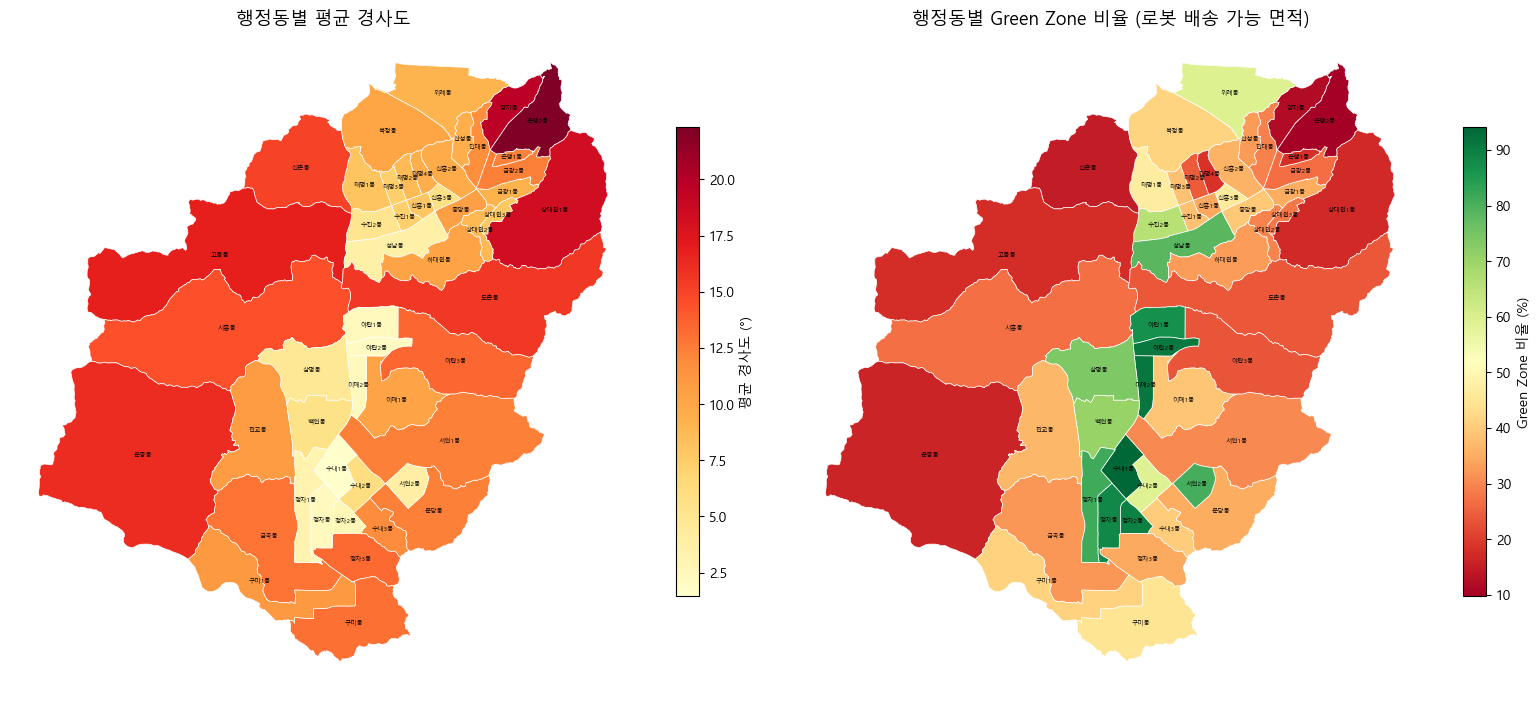

In [13]:
# 행정동별 평균 경사도 코로플레스 지도
seongnam_with_slope = seongnam_dong.copy()
adm_col = 'SHP_ADM_CD' if 'SHP_ADM_CD' in seongnam_dong.columns else 'ADM_CD'
df_stats['_adm_key'] = df_stats['SHP_ADM_CD']
seongnam_with_slope = seongnam_with_slope.merge(
    df_stats[['SHP_ADM_CD','avg_slope','green_pct','red_pct']],
    left_on=adm_col, right_on='SHP_ADM_CD', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 평균 경사도
seongnam_with_slope.plot(
    column='avg_slope', ax=axes[0],
    cmap='YlOrRd', edgecolor='white', linewidth=0.5,
    legend=True, legend_kwds={'label': '평균 경사도 (°)', 'shrink': 0.7}
)
for _, row in seongnam_with_slope.iterrows():
    c = row.geometry.centroid
    axes[0].annotate(row['ADM_NM'], xy=(c.x, c.y), fontsize=4.5, ha='center', va='center')
axes[0].set_title('행정동별 평균 경사도', fontsize=13)
axes[0].set_axis_off()

# Green Zone 비율
seongnam_with_slope.plot(
    column='green_pct', ax=axes[1],
    cmap='RdYlGn', edgecolor='white', linewidth=0.5,
    legend=True, legend_kwds={'label': 'Green Zone 비율 (%)', 'shrink': 0.7}
)
for _, row in seongnam_with_slope.iterrows():
    c = row.geometry.centroid
    axes[1].annotate(row['ADM_NM'], xy=(c.x, c.y), fontsize=4.5, ha='center', va='center')
axes[1].set_title('행정동별 Green Zone 비율 (로봇 배송 가능 면적)', fontsize=13)
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

In [14]:
# 최종 출력 요약
print('=' * 55)
print('NB03b 출력 파일 요약')
print('=' * 55)
outputs = [
    (dem_path,   f'DEM 래스터 ({RESOLUTION}m, EPSG:5179)'),
    (slope_path, f'경사도 래스터 (도, EPSG:5179)'),
    (zone_path,  'Zone 벡터 (Green/Yellow/Red)'),
    (stats_path, f'동별 경사도 통계 ({len(df_stats)} 개 동)'),
]
for path, desc in outputs:
    size_kb = path.stat().st_size / 1024 if path.exists() else 0
    print(f'  {path.name:<40s}  {size_kb:>8.0f} KB  {desc}')
print()
print(f'성남시 전체 Green Zone:  {green_pct:.1f}%')
print(f'성남시 전체 Yellow Zone: {yellow_pct:.1f}%')
print(f'성남시 전체 Red Zone:    {red_pct:.1f}%')

NB03b 출력 파일 요약
  seongnam_dem_b010.tif                         9620 KB  DEM 래스터 (10m, EPSG:5179)
  seongnam_slope_b010.tif                       9620 KB  경사도 래스터 (도, EPSG:5179)
  slope_zones_b010.gpkg                         9596 KB  Zone 벡터 (Green/Yellow/Red)
  dong_slope_stats_b010.csv                        6 KB  동별 경사도 통계 (50 개 동)

성남시 전체 Green Zone:  18.8%
성남시 전체 Yellow Zone: 15.6%
성남시 전체 Red Zone:    23.1%
